In [1]:
from basic_packages import *

In [2]:
def show_gradient(cmap):
    gradient = np.linspace(0, 1, 256).reshape(1, -1)

    fig, ax = plt.subplots(figsize=(10, 1.5))

    ax.imshow(
        gradient,
        aspect="auto",
        cmap=cmap
    )

    ax.set_axis_off()

    plt.show()

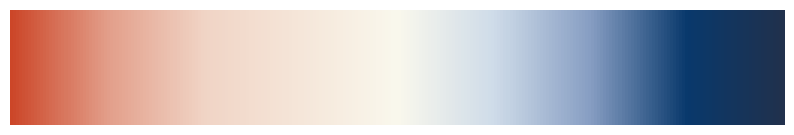

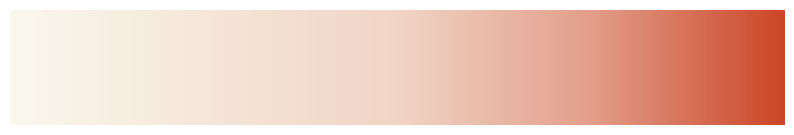

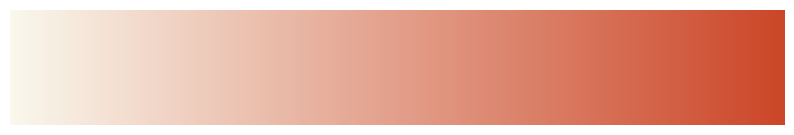

In [3]:
cream = "#FAF8ED"

red_shades = LinearSegmentedColormap.from_list(
    "red_shades",
    [cream, colorado_red]
)

pale_red = red_shades(0.25)

mines_colors_div=[
    colorado_red,
    red_shades(0.5),
    red_shades(0.2),
    red_shades(0.1),
    cream,
    pale_blue,
    light_blue,
    blaster_blue,
    dark_blue
]

mines_cmap_div = LinearSegmentedColormap.from_list(
    "mines_cmap_div",
    mines_colors_div
)

show_gradient(mines_cmap_div)

mines_colors_err=[
    cream,
    red_shades(0.1),
    red_shades(0.2),
    red_shades(0.5),
    colorado_red
]

mines_cmap_err = LinearSegmentedColormap.from_list(
    "mines_cmap_err",
    mines_colors_err
)
show_gradient(mines_cmap_err)
show_gradient(red_shades)

In [4]:
def f(x):
    return np.exp(np.sin(x))


In [5]:
#Create an array of values from 0 to 2 at which to evaluate the function.

x_vals = np.linspace(0, 2, 51)*np.pi
x_vals

h = 2*np.pi/50
h_test = x_vals[5]-x_vals[4]

#Evaluate!

f_vals = f(x_vals)

In [6]:
[h, h_test]

[0.12566370614359174, np.float64(0.12566370614359168)]

In [7]:
#Note that N here is going to be the number of grid points, not the number of grid spaces.

def approx_der_second_order(f, a, b, N):
    x_vals = np.linspace(a, b, N)
    f_vals = f(x_vals)
    h = (b-a)/(N-1)

    #Pick a random index of x_vals
    i = np.random.randint(1, N-2)
    #Make sure h and observed space between x matches
    assert np.isclose(x_vals[i+1] - x_vals[i], h)
    print(f"h: {h}", "observed spacing:", x_vals[i+1] - x_vals[i])
    
    f_prime_approx = np.array([(f_vals[1]-f_vals[0])/h] + [(f_vals[i+1]-f_vals[i-1])/(2*h) for i in range(1, N-1)] + [(f_vals[N-1]-f_vals[N-2])/h])

    return x_vals, f_prime_approx

x_vals, f_prime_approx = approx_der_second_order(f, 0, 2*np.pi, 50)

h: 0.1282282715750936 observed spacing: 0.1282282715750931


In [8]:
def fprime(x):
    return np.cos(x) * np.exp(np.sin(x))

f_prime = fprime(x_vals)

f_prime - f_prime_approx

array([-6.38324711e-02,  1.25302982e-03,  2.83354650e-03,  4.68955218e-03,
        6.67719385e-03,  8.57773453e-03,  1.01151050e-02,  1.09946437e-02,
        1.09593982e-02,  9.85295256e-03,  7.67203326e-03,  4.59123839e-03,
        9.47889130e-04, -2.81372880e-03, -6.22637967e-03, -8.89009180e-03,
       -1.05443341e-02, -1.11042132e-02, -1.06547877e-02, -9.41038981e-03,
       -7.65461393e-03, -5.67893772e-03, -3.73428302e-03, -2.00286096e-03,
       -5.90519531e-04,  4.65187606e-04,  1.17805173e-03,  1.59377824e-03,
        1.77260472e-03,  1.77628358e-03,  1.65991546e-03,  1.46797247e-03,
        1.23335977e-03,  9.78340866e-04,  7.16379553e-04,  4.54259442e-04,
        1.94128053e-04, -6.46676219e-05, -3.23940334e-04, -5.85119084e-04,
       -8.47672310e-04, -1.10737798e-03, -1.35437796e-03, -1.57106753e-03,
       -1.73005398e-03, -1.79267344e-03, -1.70886135e-03, -1.41945628e-03,
       -8.62144809e-04,  6.38684197e-02])

findfont: Font family 'Computer Modern Roman' not found.
findfont: Font family ['Computer Modern Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Computer Modern Roman' not found.
findfont: Font family ['Computer Modern Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Computer Modern Roman' not found.


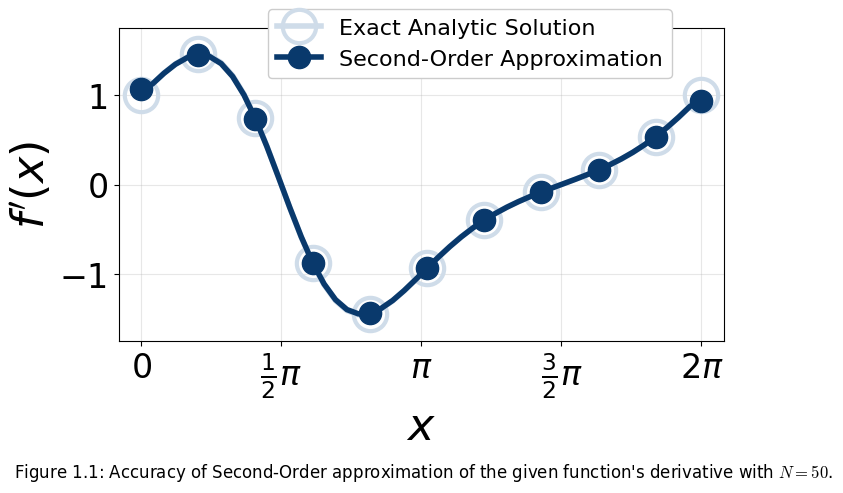

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

marks = list(range(0, len(x_vals), 5))
#Add the last index to the marks list
marks.append(len(x_vals) - 1)

ax.plot(
    x_vals, 
    f_prime, 
    linewidth=4, 
    label="Exact Analytic Solution", 
    color=pale_blue,
    marker="o",
    markerfacecolor="none",
    markeredgewidth=3,
    markersize=24,
    markevery=marks)
ax.plot(
    x_vals, 
    f_prime_approx, 
    linewidth=4, 
    label="Second-Order Approximation", 
    color=blaster_blue,
    marker="o",
    markevery=marks,
    markersize=16)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f'(x)$")


ax.xaxis.label.set_fontfamily("Computer Modern Roman")
ax.yaxis.label.set_fontfamily("Computer Modern Roman")

ax.grid(alpha=0.3)

fig.tight_layout()
fig.subplots_adjust(bottom=0.18)

[x_min, x_max] = [-0.25, 2*np.pi+0.25]
ax.set_xlim(x_min, x_max)
[y_min, y_max] = [-1.75, 1.75]
ax.set_ylim(y_min, y_max)

ax.set_xticks([
    0,
    np.pi/2,
    np.pi,
    3*np.pi/2,
    2*np.pi
])

ax.set_xticklabels([
    r"$0$",
    r"$\frac{1}{2}\pi$",
    r"$\pi$",
    r"$\frac{3}{2}\pi$",
    r"$2\pi$"
])

plt.rcParams["mathtext.fontset"] = "cm"

ax.tick_params(axis="both", labelsize=24)
ax.set_xlabel(r"$x$", fontsize=32, fontfamily="Computer Modern Roman")
ax.set_ylabel(r"$f'(x)$", fontsize=32, fontfamily="Computer Modern Roman")
ax.legend(
    loc ="center",
    bbox_to_anchor=(0.58, 0.95),
    prop={"family": "DejaVu Sans", "size": 16},
    framealpha=1
)

fig.text(
    0.55, -0.16,
    r"Figure 1.1: Accuracy of Second-Order approximation of the given function's derivative with $N = 50$.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

plt.show()

In [10]:
fig.savefig(
    "figure_1_1.pdf",
    bbox_inches="tight"
)

findfont: Font family 'Computer Modern Roman' not found.
findfont: Font family 'Computer Modern Roman' not found.


In [11]:
# x_vals, f_prime_approx = approx_der_second_order(f, 0, 2*np.pi, 50)



In [12]:
start = 10
M = 15

N_vals = start * 2**np.arange(M)
h_vals = 2*np.pi/(N_vals-1)

x_vals_list = []
f_prime_approx_list = []
for N in N_vals:
    x_vals, f_prime_approx = approx_der_second_order(f, 0, 2*np.pi, N)
    x_vals_list.append(x_vals)
    f_prime_approx_list.append(f_prime_approx)

f_prime_list = []
for x in x_vals_list:
    f_prime_list.append(np.cos(x)*np.exp(np.sin(x)))

h: 0.6981317007977318 observed spacing: 0.6981317007977317
h: 0.3306939635357677 observed spacing: 0.33069396353576774
h: 0.16110731556870733 observed spacing: 0.1611073155687075
h: 0.07953399123012135 observed spacing: 0.07953399123012117
h: 0.039516888724399915 observed spacing: 0.039516888724399735
h: 0.01969650566513977 observed spacing: 0.019696505665139696
h: 0.009832840856306082 observed spacing: 0.009832840856306202
h: 0.0049125764716024915 observed spacing: 0.004912576471602037
h: 0.0024553283732628318 observed spacing: 0.0024553283732626774
h: 0.0012274243616291437 observed spacing: 0.001227424361628593
h: 0.000613652242131027 observed spacing: 0.0006136522421309465
h: 0.0003068111385897547 observed spacing: 0.0003068111385897687
h: 0.00015340182395028165 observed spacing: 0.00015340182395029434
h: 7.669997567328197e-05 observed spacing: 7.669997567338882e-05
h: 3.8349753765462355e-05 observed spacing: 3.834975376548755e-05


In [13]:
errors_inf = []
errors_2 = []

for i in range(len(x_vals_list)):
    errors_inf.append(np.max(np.abs(f_prime_list[i] - f_prime_approx_list[i]))/np.max(np.abs(f_prime_list[i])))
    errors_2.append(np.linalg.norm(f_prime_list[i] - f_prime_approx_list[i])/np.linalg.norm(f_prime_list[i]))

[errors_inf, errors_2]

[[np.float64(0.22019772095720364),
  np.float64(0.11079607950024693),
  np.float64(0.05493027791474274),
  np.float64(0.027226785329837567),
  np.float64(0.01354212404667754),
  np.float64(0.006751625409119671),
  np.float64(0.003370749096262029),
  np.float64(0.001684077022213771),
  np.float64(0.0008417130747260714),
  np.float64(0.000420774759052099),
  np.float64(0.00021036687966506426),
  np.float64(0.00010517830927715124),
  np.float64(5.2587872029014465e-05),
  np.float64(2.6293615569099502e-05),
  np.float64(1.314674220118784e-05)],
 [np.float64(0.21245370953939804),
  np.float64(0.06795310531506171),
  np.float64(0.022026583023789497),
  np.float64(0.007387536998939788),
  np.float64(0.002537756234485391),
  np.float64(0.00088385319978838),
  np.float64(0.0003101010544317803),
  np.float64(0.00010921309651587872),
  np.float64(3.853750041374159e-05),
  np.float64(1.3611762033946233e-05),
  np.float64(4.81013180031718e-06),
  np.float64(1.7002223539006088e-06),
  np.float64(6.0

C:\Users\cjgir\AppData\Local\Temp\ipykernel_34404\2830624951.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


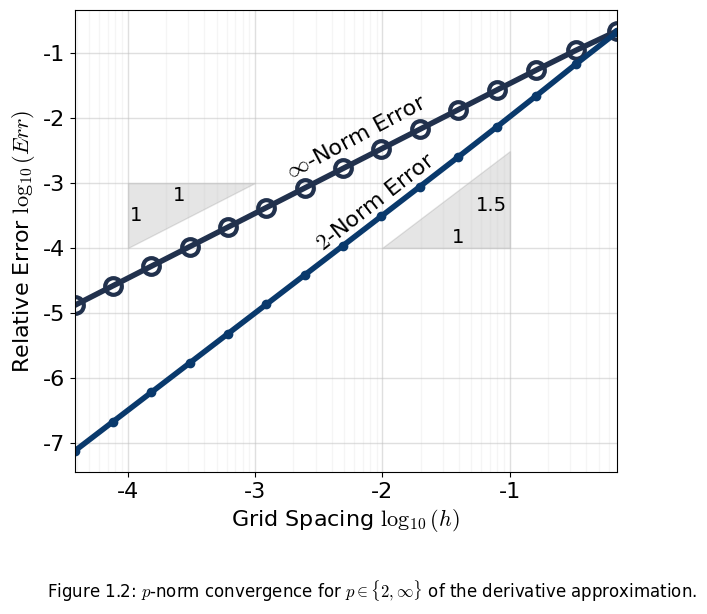

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.loglog(
    h_vals, 
    errors_inf, 
    label='Infinity Norm Error', 
    color=dark_blue, 
    linewidth=4, 
    marker="o",
    markerfacecolor="none",
    markeredgewidth=3,
    markersize=12)
ax.loglog(h_vals, errors_2, label='2-Norm Error', color=blaster_blue, linewidth=4, marker="o")
ax.set_xlabel(r"Grid Spacing $\log_{10}(h)$", fontsize=16)
ax.set_ylabel(r"Relative Error $\log_{10}(Err)$", fontsize=16)
ax.grid(True, which="major", linewidth=1, alpha=0.5, color='silver')
ax.grid(True, which="minor", linewidth=1, alpha=0.15, color='silver')
ax.grid(False, axis="y", which="minor")
ax.tick_params(axis="both", labelsize=16)
ax.set_xlim(np.min(h_vals), np.max(h_vals))
ax.set_yticks([
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
])
ax.tick_params(
    which="minor",
    length=0,       # hide tick marks
    labelsize=0     # hide minor tick labels
)
ax.set_yticklabels([
    r"-7", r"-6", r"-5", r"-4", r"-3", r"-2", r"-1"
])
ax.set_xticklabels([
    'wtf',
    'wtf',
    '-4',
    '-3',
    '-2',
    '-1'
])

x00 = 1e-4
y00 = 1e-4
x01 = 1e-3
y01 = 1e-3

# triangle
ax.fill(
    [x00, x00, x01],
    [y00, y01, y01],
    color="black",
    alpha=0.1
)

ax.text(
    np.sqrt(x00*x01)*0.8, y01*0.9,
    r"1",
    ha="center", va="top",
    fontdict={"size": 14}
)

ax.text(
    x00*1.05, np.sqrt(y00*y01),
    r"1",
    ha="left", va="center",
    fontdict={"size": 14}
)

x10 = 1e-2
y10 = 1e-4
x11 = 1e-1
y11 = 10**-2.5

ax.fill(
    [x10, x11, x11],
    [y10, y10, y11],
    color="black",
    alpha=0.1
)

ax.text(
    np.sqrt(x10*x11)*1.25, y10*1.05,
    r"1",
    ha="center", va="bottom",
    fontdict={"size": 14}
)

ax.text(
    x11*0.95, np.sqrt(y10*y11)*.8,
    r"1.5",
    ha="right", va="center",
    fontdict={"size": 14}
)

ax.text(
    10**-2.2, 10**-2.3,
    r"$\infty$-Norm Error",
    rotation=28,
    ha="center", va="center",
    fontdict={"size": 16}
)

ax.text(
    10**-2.05, 10**-3.3,
    r"$2$-Norm Error",
    rotation=38,
    ha="center", va="center",
    fontdict={"size": 16}
)

fig.text(
    0.55, -0.1,
    r"Figure 1.2: $p$-norm convergence for $p \in \{2, \infty\}$ of the derivative approximation.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

plt.show()
plt.show()

In [15]:
fig.savefig(
    "figure_1_2.pdf",
    bbox_inches="tight"
)

Explanation of the $3/2$ slope:

We begin with the given equation for the $2$-norm error:

$$
    Err_2 = \frac{\lVert f'(x) - f_n'(x)\rVert_2}{\lVert f'(x) \rVert_2}
$$

When order notation is introduced, the $3/2$ slope property appears.
To begin, state that for all $x_i$, its derivative does not depend on $h$:
$$
    f'(x_i) \to O(1), \quad i \in \{1,2,\dots,N\}
$$
Next, consider the error of the first-order-evaluated endpoints, for which it is well known their error scales with $h$:
$$
    \lvert f'(x_i) - f_n'(x_i) \lvert \to O(h), \quad i=1,N
$$
Similarly, the error for the second-order-evaluated interior points:
$$
    \lvert f'(x_i) - f_n'(x_i) \lvert \to O(h^2), \quad i \in \{2,3,\dots,N-1\}
$$
Therefore the $2$-norm of the error at $x_i$ and the analytic solution at $x_i$ can be calculated:
$$
    \lVert f'(x) - f_n'(x)\rVert_2 = \left( \sum_{i=1}^{N} f'(x_i) - f_n'(x_i)^2 \right)^{1/2} \\
    \to \sqrt{O(h)^2 + O(N) \cdot  O(h^2)^2},
$$
where $O(h)$ comes from the two endpoints' error. Following simplifications:
$$
    O(h)^2 = O(h^2),\\
    O(N) \cdot O(h^2)^2 = O(h^3) \quad (\text{by } N \to O(1/h)),\\
    O(h^2) + O(h^3) = O(h^2) \quad (\text{by }h\text{ small}),\\
    \sqrt{O(h^2)} = O(h)
$$
the order of the numerator term (that is, the norm of the error at every $x_i$) is yielded:
$$
    \lVert f'(x) - f_n'(x)\rVert_2 \to O(h)
$$
A similar and more straightford process occurs for the denominator term (that is, the norm of the analytic solution at every $x_i$):
$$
    \lVert f'(x) \rVert_2 = \left( \sum_{i=1}^N f'(x_i) \right)^{1/2} \\
    \to \sqrt{O(N)} \\
    = O(h^{-1/2})
$$
Therefore the order for the convergence emerges:
$$
    Err_2 \to \frac{O(h)}{O(h^{-1/2})} = O(h^{3/2}) = O(\frac{1}{N^{3/2}})
$$

In [16]:
#Create an array of values from 0 to 2 at which to evaluate the function.



In [17]:
def approx_second_der(f, a, b, N):
    x_vals = np.linspace(a,b,N)
    f_vals=f(x_vals)
    h = (b-a)/(N-1)

    #Note that f(x_1) = f(x_N) Therefore to use the periodicity condition, we say that the point to the "left" of x_1 is x_N-1.
    endpoints_approx = (f_vals[-2]-2*f_vals[0]+f_vals[1])/h**2
    f_double_prime_approx = np.array([endpoints_approx] + [(f_vals[i-1]-2*f_vals[i]+f_vals[i+1])/h**2 for i in range(1, N-1)] + [endpoints_approx])

    return x_vals, f_double_prime_approx

x_vals, f_double_prime_approx = approx_second_der(f, 0, 2*np.pi, 51)

def f_double_prime(x):
    return (np.cos(x)**2-np.sin(x))*np.exp(np.sin(x))

f_double_prime_vals = f_double_prime(x_vals)

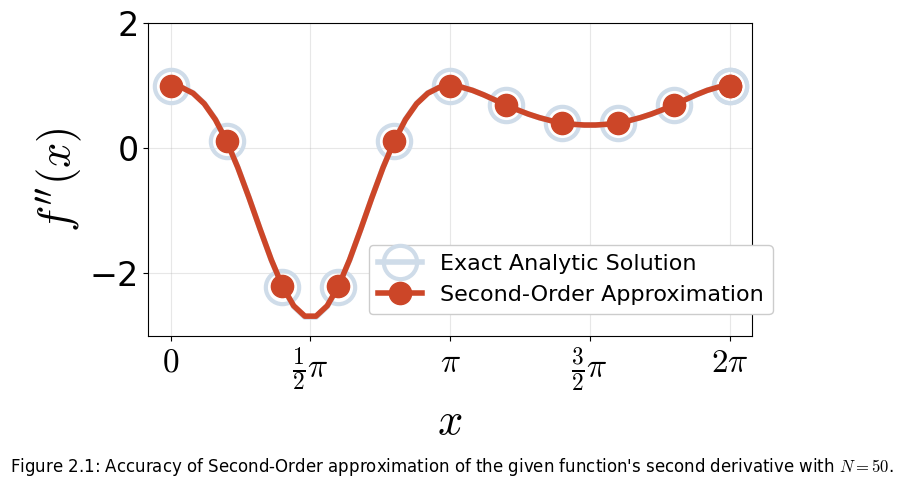

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))

marks = list(range(0, len(x_vals), 5))
#Add the last index to the marks list
marks.append(len(x_vals) - 1)

ax.plot(
    x_vals, 
    f_double_prime_vals, 
    linewidth=4, 
    label="Exact Analytic Solution", 
    color=pale_blue,
    marker="o",
    markerfacecolor="none",
    markeredgewidth=3,
    markersize=24,
    markevery=marks)
ax.plot(
    x_vals, 
    f_double_prime_approx, 
    linewidth=4, 
    label="Second-Order Approximation", 
    color=colorado_red,
    marker="o",
    markevery=marks,
    markersize=16)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f'(x)$")

ax.grid(alpha=0.3)

fig.tight_layout()
fig.subplots_adjust(bottom=0.18)

[x_min, x_max] = [-0.25, 2*np.pi+0.25]
ax.set_xlim(x_min, x_max)
[y_min, y_max] = [-3, 2]
ax.set_ylim(y_min, y_max)

ax.set_xticks([
    0,
    np.pi/2,
    np.pi,
    3*np.pi/2,
    2*np.pi
])

ax.set_xticklabels([
    r"$0$",
    r"$\frac{1}{2}\pi$",
    r"$\pi$",
    r"$\frac{3}{2}\pi$",
    r"$2\pi$"
])

plt.rcParams["mathtext.fontset"] = "cm"

ax.tick_params(axis="both", labelsize=24)
ax.set_xlabel(r"$x$", fontsize=32)
ax.set_ylabel(r"$f''(x)$", fontsize=32)
ax.legend(
    loc ="center",
    bbox_to_anchor=(0.7, 0.18),
    prop={"family": "DejaVu Sans", "size": 16},
    framealpha=1
)

fig.text(
    0.55, -0.16,
    r"Figure 2.1: Accuracy of Second-Order approximation of the given function's second derivative with $N=50$.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

plt.show()

In [19]:
fig.savefig(
    "figure_2_1.pdf",
    bbox_inches="tight"
)

In [20]:
start = 10
M = 15

N_vals = start * 2**np.arange(M)
h_vals = 2*np.pi/(N_vals-1)

x_vals_list = []
f_double_prime_approx_list = []
for N in N_vals:
    x_vals, f_double_prime_approx = approx_second_der(f, 0, 2*np.pi, N)
    x_vals_list.append(x_vals)
    f_double_prime_approx_list.append(f_double_prime_approx)

f_double_prime_list = []
for x in x_vals_list:
    f_double_prime_list.append(f_double_prime(x))

errors_inf = []
errors_2 = []

for i in range(len(x_vals_list)):
    errors_inf.append(np.max(np.abs(f_double_prime_list[i] - f_double_prime_approx_list[i]))/np.max(np.abs(f_double_prime_list[i])))
    errors_2.append(np.linalg.norm(f_double_prime_list[i] - f_double_prime_approx_list[i])/np.linalg.norm(f_double_prime_list[i]))

[errors_inf, errors_2]

[[np.float64(0.13673665446310396),
  np.float64(0.03500594741428439),
  np.float64(0.008568213105735887),
  np.float64(0.002103553216018509),
  np.float64(0.0005202230736640487),
  np.float64(0.00012929860804543293),
  np.float64(3.2227086109726955e-05),
  np.float64(8.044398528793167e-06),
  np.float64(2.009557635727961e-06),
  np.float64(5.023095473534952e-07),
  np.float64(1.2631807712597222e-07),
  np.float64(3.506871012637838e-08),
  np.float64(2.8850542730129448e-08),
  np.float64(1.0070859890999703e-07),
  np.float64(4.156405029104085e-07)],
 [np.float64(0.1334113956716759),
  np.float64(0.032389026194606846),
  np.float64(0.007845599211903422),
  np.float64(0.0019230488507740512),
  np.float64(0.00047559094776709817),
  np.float64(0.000118229525612105),
  np.float64(2.9472549118962176e-05),
  np.float64(7.35745341948194e-06),
  np.float64(1.83802293346568e-06),
  np.float64(4.593378968836745e-07),
  np.float64(1.1481551362921496e-07),
  np.float64(2.8849699128091747e-08),
  np.

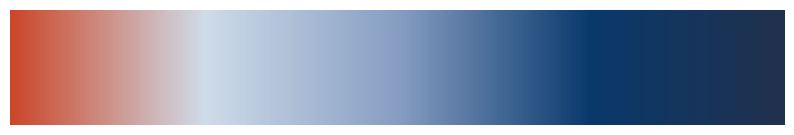

In [21]:
mines_colors=[
    colorado_red,
    pale_blue,
    light_blue,
    blaster_blue,
    dark_blue
]

mines_cmap = LinearSegmentedColormap.from_list(
    "mines_cmap",
    mines_colors
)

show_gradient(mines_cmap)

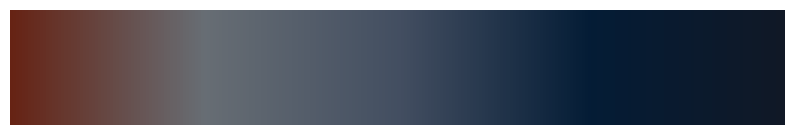

In [22]:
def darken(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

mines_colors_darker = [darken(color, factor=0.5) for color in mines_colors]
mines_cmap_darker = LinearSegmentedColormap.from_list(
    "mines_cmap_darker",
    mines_colors_darker
)
show_gradient(mines_cmap_darker)



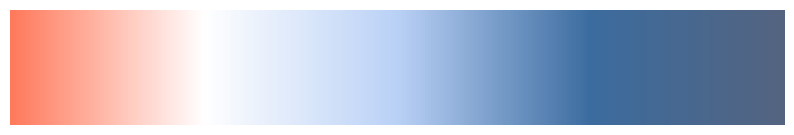

In [23]:
def enrichen(color, factor=0.2):
    c = mcolors.to_rgb(color)
    enriched_color = tuple(min(1, x + factor) for x in c)
    return enriched_color

mines_colors_enriched = [enrichen(color) for color in mines_colors]
mines_cmap_enriched = LinearSegmentedColormap.from_list(
    "mines_cmap_enriched",
    mines_colors_enriched
)
show_gradient(mines_cmap_enriched)

C:\Users\cjgir\AppData\Local\Temp\ipykernel_34404\3511186094.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


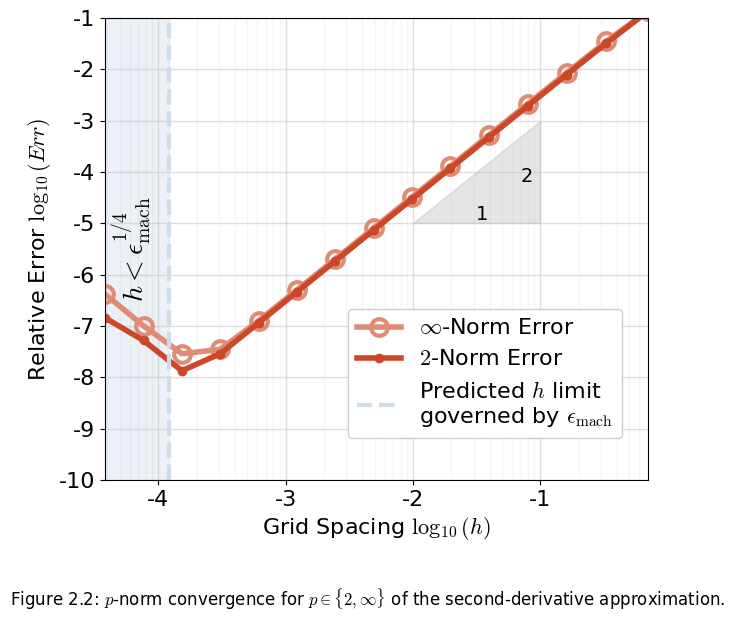

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.loglog(
    h_vals, 
    errors_inf, 
    label=r"$\infty$-Norm Error", 
    color=mines_cmap_div(0.1), 
    linewidth=4, 
    marker="o",
    markerfacecolor="none",
    markeredgewidth=3,
    markersize=12)
ax.loglog(h_vals, errors_2, label=r"$2$-Norm Error", color=colorado_red, linewidth=4, marker="o")
ax.set_xlabel(r"Grid Spacing $\log_{10}(h)$", fontsize=16)
ax.set_ylabel(r"Relative Error $\log_{10}(Err)$", fontsize=16)
ax.grid(True, which="major", linewidth=1, alpha=0.5, color='silver')
ax.grid(True, which="minor", linewidth=1, alpha=0.15, color='silver')
ax.tick_params(axis="both", labelsize=16)
ax.set_xlim(np.min(h_vals), np.max(h_vals))
ax.set_ylim(10**-10, 10**-1)
ax.set_yticks([
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
])
ax.tick_params(
    which="minor",
    length=0,       # hide tick marks
    labelsize=0     # hide minor tick labels
)
ax.set_yticklabels([
    r"-10", r"-9", r"-8", r"-7", r"-6", r"-5", r"-4", r"-3", r"-2", r"-1"
])
ax.set_xticklabels([
    'wtf',
    'wtf',
    '-4',
    '-3',
    '-2',
    '-1'
])

x00 = 1e-2
y00 = 1e-5
x01 = 1e-1
y01 = 1e-3

# triangle
ax.fill(
    [x00, x01, x01],
    [y00, y00, y01],
    color="black",
    alpha=0.1
)

ax.text(
    np.sqrt(x00*x01)*1.1, y00*2.3,
    r"1",
    ha="center", va="top",
    fontdict={"size": 14}
)

ax.text(
    x01*0.7, np.sqrt(y00*y01)*0.8,
    r"2",
    ha="left", va="center",
    fontdict={"size": 14}
)

fig.text(
    0.5, -0.1,
    r"Figure 2.2: $p$-norm convergence for $p \in \{2, \infty\}$ of the second-derivative approximation.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

h_limit = np.finfo(float).eps ** (1/4)

ax.axvline(
    x=h_limit,
    linestyle="--",
    linewidth=3,
    alpha=1,
    color=pale_blue,
    label="Predicted $h$ limit \n"+r"governed by $\epsilon_\text{mach}$"
)

ax.text(
    10**-4.2, 10**-5.5,
    r"$h<\epsilon_\text{mach}^{1/4}$",
    rotation=90,
    ha="center", va="center",
    fontdict={"size": 20}
)

ax.axvspan(
    ax.get_xlim()[0], h_limit,
    alpha=0.4,
    color=pale_blue
)

ax.legend(
    loc ="center",
    bbox_to_anchor=(0.7, 0.23),
    prop={"family": "DejaVu Sans", "size": 16},
    framealpha=1
)

plt.show()

In [25]:
fig.savefig(
    "figure_2_2.pdf",
    bbox_inches="tight"
)

Using $u(x) = \sin(x)$ and $f(x) = \frac{1}{2}\sin(2x)$

Evaluate $u$ at $x=0,5$ to determine the Dirichlet boundary conditions.

In [26]:
def u(x):
    return np.sin(x)

def f(x):
    return 1/2*np.sin(2*x)

boundary_x = [0, 5]
boundary_u = [u(x) for x in boundary_x]

Derive $f(x_i)$ in terms of $u, i$: 

$$
\frac{d^2u}{dx^2} \cong \frac{u(x_{i-1})-2u(x_i)+u(x_{i+1})}{h^2}, \\
\sin(x_i)\frac{du}{dx} \cong \sin(x_i)\frac{u(x_{i+1})-u(x_{i-1})}{2h}, \\
f(x) \cong \frac{u(x_{i-1})-2u(x_i)+u(x_{i+1})}{h^2} + \sin(x_i)\frac{u(x_{i+1})-u(x_{i-1})}{2h} + u(x_i), \\
f(x) \cong \left( \frac{1}{h^2} - \frac{\sin(x_i)}{2h} \right) u(x_{i-1}) + \left( \frac{-2}{h^2} + 1 \right) u(x_i) + \left( \frac{1}{h^2} + \frac{\sin(x_i)}{2h} \right) u(x_{i+1})
$$

In [27]:
N = 50
a = 0
b = 5

x_vals = np.linspace(a, b, N+1)
h = (b - a)/N

def Dirichlet_Matrix_2O_1D(boundary_value, x_vals, deriv_coeff, f):
    assert (
        len(boundary_value) == 2
        and (
            all(isinstance(val, (int, float)) or callable(val) for val in boundary_value)
        )
    ), "Boundary values must be two numeric values or callable functions."
    assert callable(f), "f must be a callable function."
    assert (
        len(deriv_coeff) == 3
        and (
            all(isinstance(val, (int, float)) or callable(val) for val in deriv_coeff)
        )
    ), "deriv_coeff must be three numeric values or callable functions."

    N = len(x_vals) - 1
    h = x_vals[1] - x_vals[0]

    c_0 = deriv_coeff[0](x_vals) if callable(deriv_coeff[0]) else np.full_like(x_vals, deriv_coeff[0])
    c_1 = deriv_coeff[1](x_vals) if callable(deriv_coeff[1]) else np.full_like(x_vals, deriv_coeff[1])
    c_2 = deriv_coeff[2](x_vals) if callable(deriv_coeff[2]) else np.full_like(x_vals, deriv_coeff[2])

    main = (c_2 * (-2/(h**2)) + c_0)[1:-1]
    lower = (c_2 * (1/(h**2)) - c_1 * (1/(2*h)))[2:-1]
    upper = (c_2 * (1/(h**2)) + c_1 * (1/(2*h)))[1:-2]

    A = sp.sparse.diags([lower, main, upper], offsets=[-1, 0, 1], format='csc')

    b = f(x_vals[1:-1])
    b[0] -= (c_2[0] * (1/(h**2)) - c_1[0] * (1/(2*h))) * boundary_value[0]
    b[-1] -= (c_2[-1] * (1/(h**2)) + c_1[-1] * (1/(2*h))) * boundary_value[1]

    return A, b, [c_0, c_1, c_2], [main, lower, upper]

def Solve_Dirichlet_2O_1D(boundary_value, x_vals, deriv_coeff, f):
    A, b, c_vals, matrix_vals = Dirichlet_Matrix_2O_1D(boundary_value, x_vals, deriv_coeff, f)
    u_approx = np.array([boundary_value[0]] + list(sp.sparse.linalg.spsolve(A, b)) + [boundary_value[1]])
    return u_approx


In [28]:
u_approx = Solve_Dirichlet_2O_1D(boundary_value=boundary_u, x_vals=x_vals, deriv_coeff=[1, np.sin, 1], f=f)
u_approx

array([ 0.        ,  0.1001482 ,  0.19929346,  0.29644298,  0.39062419,
        0.48089449,  0.56635081,  0.64613862,  0.7194605 ,  0.78558404,
        0.84384913,  0.89367447,  0.93456329,  0.96610824,  0.98799537,
        1.00000719,  1.00202483,  0.99402913,  0.97610082,  0.94841974,
        0.91126297,  0.86500213,  0.81009965,  0.74710416,  0.67664507,
        0.59942625,  0.51621907,  0.4278547 ,  0.33521581,  0.23922783,
        0.14084965,  0.04106414, -0.05913169, -0.15873662, -0.25675518,
       -0.35220762, -0.44413962, -0.53163182, -0.61380901, -0.68984883,
       -0.75898998, -0.82053979, -0.8738812 , -0.91847886, -0.95388457,
       -0.97974175, -0.99578905, -1.00186311, -0.99790021, -0.98393708,
       -0.95892427])

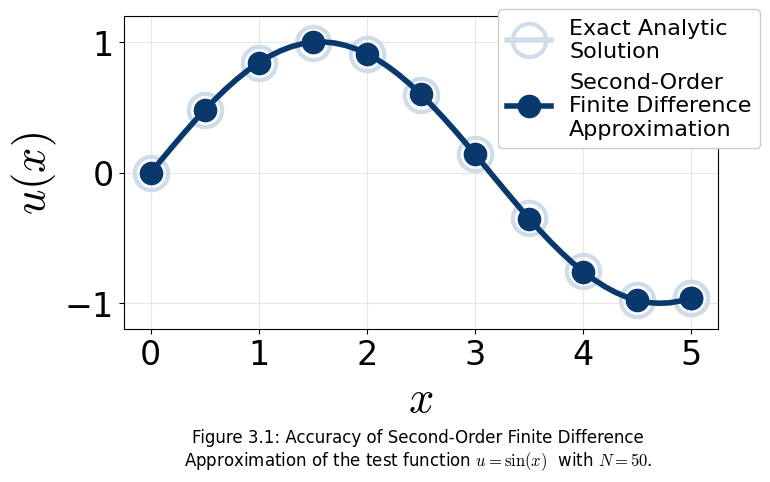

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))

marks = list(range(0, len(x_vals), 5))
#Add the last index to the marks list
marks.append(len(x_vals) - 1)

ax.plot(
    x_vals, 
    u(x_vals), 
    linewidth=4, 
    label="Exact Analytic\nSolution", 
    color=pale_blue,
    marker="o",
    markerfacecolor="none",
    markeredgewidth=3,
    markersize=24,
    markevery=marks)
ax.plot(
    x_vals, 
    u_approx, 
    linewidth=4, 
    label="Second-Order\nFinite Difference\nApproximation", 
    color=blaster_blue,
    marker="o",
    markevery=marks,
    markersize=16)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u(x)$")

ax.grid(alpha=0.3)

fig.tight_layout()
fig.subplots_adjust(bottom=0.18)

[x_min, x_max] = [-0.25, 5+0.25]
ax.set_xlim(x_min, x_max)
[y_min, y_max] = [-1.2, 1.2]
ax.set_ylim(y_min, y_max)

plt.rcParams["mathtext.fontset"] = "cm"

ax.tick_params(axis="both", labelsize=24)
ax.set_xticks([0, 1, 2, 3, 4, 5])

ax.set_xlabel(r"$x$", fontsize=32)
ax.set_ylabel(r"$u(x)$", fontsize=32)
ax.legend(
    loc ="center",
    bbox_to_anchor=(0.85, 0.8),
    prop={"family": "DejaVu Sans", "size": 16},
    framealpha=1
)

fig.text(
    0.55, -0.16,
    "Figure 3.1: Accuracy of Second-Order Finite Difference\n"+ r"Approximation of the test function $u=\sin(x)$  with $N=50$.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

plt.show()

In [30]:
fig.savefig(
    "figure_3_1.pdf",
    bbox_inches="tight"
)

In [31]:
start = 10
M = 15

N_vals = start * 2**np.arange(M)
h_vals = 5/(N_vals)

x_vals_list = []
u_approx_list = []
for N in N_vals:
    x_vals = np.linspace(0,5,N+1)
    u_approx = Solve_Dirichlet_2O_1D(boundary_value=boundary_u, x_vals=x_vals, deriv_coeff=[1, np.sin, 1], f=f)
    x_vals_list.append(x_vals)
    u_approx_list.append(u_approx)

u_list = []
for x_vals in x_vals_list:
    u_list.append(u(x_vals))

errors_inf = []
errors_2 = []

for i in range(len(x_vals_list)):
    errors_inf.append(np.max(np.abs(u_list[i] - u_approx_list[i]))/np.max(np.abs(u_list[i])))
    errors_2.append(np.linalg.norm(u_list[i] - u_approx_list[i])/np.linalg.norm(u_list[i]))

[errors_inf, errors_2]

[[np.float64(0.048333318180180544),
  np.float64(0.014639898211087285),
  np.float64(0.003935638448670044),
  np.float64(0.0010153730854819206),
  np.float64(0.00025779501128722355),
  np.float64(6.493362999980018e-05),
  np.float64(1.6294093422840532e-05),
  np.float64(4.0810836687213665e-06),
  np.float64(1.0212131313473984e-06),
  np.float64(2.554227936326278e-07),
  np.float64(6.384690753932281e-08),
  np.float64(1.600831212050019e-08),
  np.float64(4.0907164322995846e-09),
  np.float64(7.863902862304287e-10),
  np.float64(6.756240011962927e-10)],
 [np.float64(0.045934501142776675),
  np.float64(0.013815040614069282),
  np.float64(0.003734336478111733),
  np.float64(0.0009687319530346318),
  np.float64(0.0002466129882897908),
  np.float64(6.221035536397486e-05),
  np.float64(1.562247193543368e-05),
  np.float64(3.914369614675058e-06),
  np.float64(9.796857257238897e-07),
  np.float64(2.450594750239579e-07),
  np.float64(6.126855180518864e-08),
  np.float64(1.5344763122264316e-08),


C:\Users\cjgir\AppData\Local\Temp\ipykernel_34404\3000972656.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


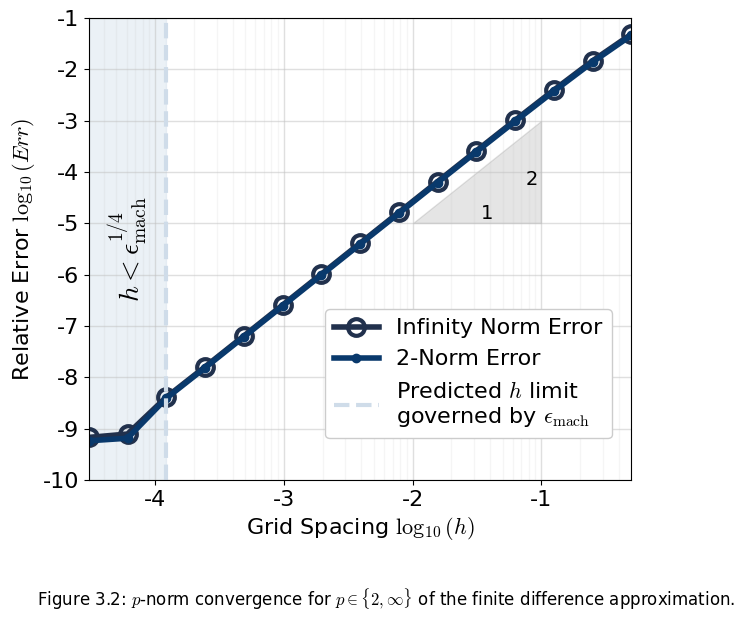

In [32]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.loglog(
    h_vals, 
    errors_inf, 
    label='Infinity Norm Error', 
    color=dark_blue, 
    linewidth=4, 
    marker="o",
    markerfacecolor="none",
    markeredgewidth=3,
    markersize=12)
ax.loglog(h_vals, errors_2, label='2-Norm Error', color=blaster_blue, linewidth=4, marker="o")
ax.set_xlabel(r"Grid Spacing $\log_{10}(h)$", fontsize=16)
ax.set_ylabel(r"Relative Error $\log_{10}(Err)$", fontsize=16)
ax.grid(True, which="major", linewidth=1, alpha=0.5, color='silver')
ax.grid(True, which="minor", linewidth=1, alpha=0.15, color='silver')
ax.tick_params(axis="both", labelsize=16)
ax.set_xlim(np.min(h_vals), np.max(h_vals))
ax.set_ylim(10**-10, 10**-1)
ax.set_yticks([
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
])
ax.tick_params(
    which="minor",
    length=0,       # hide tick marks
    labelsize=0     # hide minor tick labels
)
ax.set_yticklabels([
    r"-10", r"-9", r"-8", r"-7", r"-6", r"-5", r"-4", r"-3", r"-2", r"-1"
])
ax.set_xticklabels([
    'wtf',
    'wtf',
    '-4',
    '-3',
    '-2',
    '-1'
])

x0 = 1e-2
y0 = 1e-5
x1 = 1e-1
y1 = 1e-3

# triangle
ax.fill(
    [x0, x1, x1],
    [y0, y0, y1],
    color="black",
    alpha=0.1
)

ax.text(
    np.sqrt(x0*x1)*1.2, y0*2.4,
    r"1",
    ha="center", va="top",
    fontdict={"size": 14}
)

ax.text(
    x1*0.75, np.sqrt(y0*y1)*0.7,
    r"2",
    ha="left", va="center",
    fontdict={"size": 14}
)

fig.text(
    0.55, -0.1,
    r"Figure 3.2: $p$-norm convergence for $p \in \{2, \infty\}$ of the finite difference approximation.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

ax.axvline(
    x=h_limit,
    linestyle="--",
    linewidth=3,
    alpha=1,
    color=pale_blue,
    label="Predicted $h$ limit \n"+r"governed by $\epsilon_\text{mach}$"
)

ax.text(
    10**-4.2, 10**-5.5,
    r"$h<\epsilon_\text{mach}^{1/4}$",
    rotation=90,
    ha="center", va="center",
    fontdict={"size": 20}
)

ax.axvspan(
    ax.get_xlim()[0], h_limit,
    alpha=0.4,
    color=pale_blue
)

ax.legend(
    loc ="center",
    bbox_to_anchor=(0.7, 0.23),
    prop={"family": "DejaVu Sans", "size": 16},
    framealpha=1
)

plt.show()

In [33]:
fig.savefig(
    "figure_3_2.pdf",
    bbox_inches="tight"
)

In [34]:
N = 50
a = 0
b = 5
h = (b - a) / N

x_vals = np.row_stack((np.linspace(a,b,N+1), np.linspace(a,b,N+1)))

def u(x):
    return np.sin(x[0])*np.cos(x[1])

def f(x):
    return -2*np.sin(x[0])*np.cos(x[1])

A = sp.sparse.lil_matrix(((N-1)**2, (N-1)**2))

#Given i and j are interior points, we can get their overall interior point intex:
def get_interior_index(i, j, N):
    assert 1 <= i < N
    assert 1 <= j < N
    return (i-1)*(N-1) + (j-1)

for i in range(1, N):
    for j in range(1, N):
        A[get_interior_index(i, j, N), get_interior_index(i, j, N)] = -4    #Self-reference term
        if i > 1:
            A[get_interior_index(i, j, N), get_interior_index(i-1, j, N)] = 1 #Above neighbor compressed to row-major order
        if i < N-1:
            A[get_interior_index(i, j, N), get_interior_index(i+1, j, N)] = 1 #Below neighbor compressed to row-major order
        if j > 1:
            A[get_interior_index(i, j, N), get_interior_index(i, j-1, N)] = 1 #Left neighbor compressed to row-major order
        if j < N-1:
            A[get_interior_index(i, j, N), get_interior_index(i, j+1, N)] = 1 #Right neighbor compressed to row-major order

A = A.tocsr() * (1 / h**2)

#Now for the same thing, but for the boundary coefficients.
#There are 4N boundary points in total. Side lengths are N+1 and the corners are counted twice.

B_bd = sp.sparse.lil_matrix(((N-1)**2, 4*N))

def get_boundary_index(i, j, N):
    assert i == 0 or i == N or j == 0 or j == N, "Point is not on the boundary"
    if i == 0:
        return j  # Top boundary
    if i == N:
        return N + j + 1  # Bottom boundary
    if j == 0:
        return 2*N + i + 1 # Left boundary
    if j == N:
        return 3*N + i # Right boundary

for i in range(1, N):
    for j in range(1, N):
        if i == 1:
            B_bd[(i-1)*(N-1) + (j-1), get_boundary_index(i-1, j, N)] = 1 #Top boundary compressed to row-major order. Note that the index of the boundary matrix is offset from the interior point matrix. 
        if i == N-1:
            B_bd[(i-1)*(N-1) + (j-1), get_boundary_index(i+1, j, N)] = 1 #Bottom boundary compressed to row-major order.
        if j == 1:
            B_bd[(i-1)*(N-1) + (j-1), get_boundary_index(i, j-1, N)] = 1 #Left boundary compressed to row-major order.
        if j == N-1:
            B_bd[(i-1)*(N-1) + (j-1), get_boundary_index(i, j+1, N)] = 1 #Right boundary compressed to row-major order.

B_bd = B_bd.tocsr() * (1 / h**2)

u_bd = np.zeros(4*N)

for i in range(N+1):
    for j in range(N+1):
        if i == 0 or i == N or j == 0 or j == N:
            u_bd[get_boundary_index(i, j, N)] = u((x_vals[0][i], x_vals[1][j]))

#c'est incroyable.
#Now let's do the same thing to get the vector for f.

f_vec = np.zeros((N-1)**2)

#Amazing! Now let's calculate the boundary values and toss them into a vector
#Which will be easy because we have the boundary index function.

for i in range(1, N):
    for j in range(1, N):
        f_vec[get_interior_index(i, j, N)] = f((x_vals[0][i], x_vals[1][j]))

b = f_vec - B_bd @ u_bd

#Let's cross our fingers and solve the linear system
u_in = sp.sparse.linalg.spsolve(A, b)

#Now let's reconstruct the full solution including the boundary values
def reverse_interior_index(k, N):
    i = k // (N-1) + 1
    j = k % (N-1) + 1
    return i, j

def reverse_boundary_index(k, N):
    if k < N+1:
        return 0, k  # Top boundary
    elif k < 2*N+2:
        return N, k - (N+1)  # Bottom boundary
    elif k < 3*N+1:
        return k - (2*N+1), 0 # Left boundary
    elif k < 4*N:
        return k - (3*N), N  # Right boundary

for i in range(N+1):
    for j in range(N+1):
        if i == 0 or i == N or j == 0 or j == N:
            k = get_boundary_index(i, j, N)
            i_bd, j_bd = reverse_boundary_index(k, N)
            assert i == i_bd and j == j_bd, f"Mismatch at boundary: ({i}, {j}) != ({i_b}, {j_b})"

        else:
            k = get_interior_index(i, j, N)
            i_in, j_in = reverse_interior_index(k, N)
            assert i == i_in and j == j_in, f"Mismatch at interior: ({i}, {j}) != ({i_i}, {j_i})"

#Ha and I didn't end up needing to reverse the indices to reconstruct the full solution

u_approx = np.zeros((N+1, N+1))
for i in range(N+1):
    for j in range(N+1):
        if i == 0 or i == N or j == 0 or j == N:
            k = get_boundary_index(i, j, N)
            u_approx[i, j] = u_bd[k]
        else:
            k = get_interior_index(i, j, N)
            u_approx[i, j] = u_in[k]

u_soln = np.zeros((N+1, N+1))

for i in range(N+1):
    for j in range(N+1):
        u_soln[i, j] = u([x_vals[0][i], x_vals[1][j]])

C:\Users\cjgir\AppData\Local\Temp\ipykernel_34404\1459557977.py:6: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  x_vals = np.row_stack((np.linspace(a,b,N+1), np.linspace(a,b,N+1)))


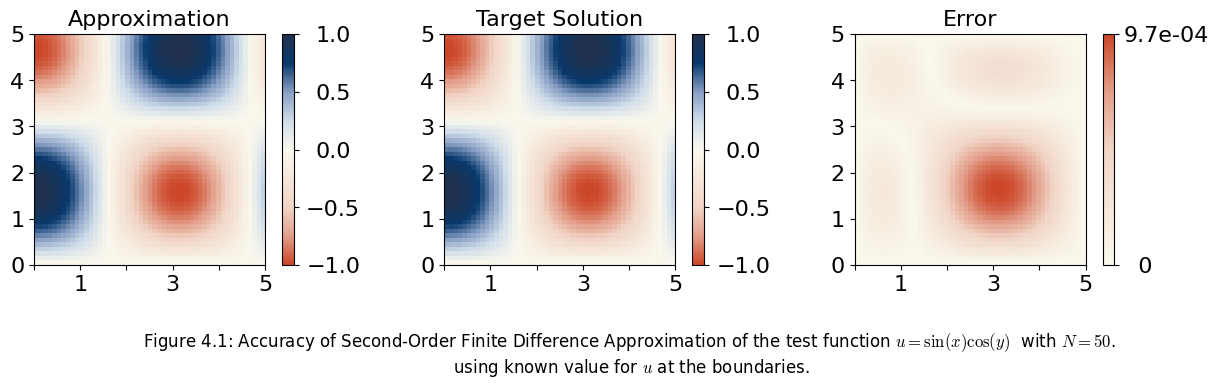

In [35]:
#Visualize the approx in 2D

from matplotlib.ticker import FuncFormatter

x = np.linspace(0, 5, N+1)
y = np.linspace(0, 5, N+1)

fig, ax = plt.subplots(1, 3, figsize=(15, 3))

im0 = ax[0].imshow(u_approx, 
    cmap=mines_cmap_div,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()])
ax[0].set_title("Approximation")
ax[0].title.set_fontsize(16)
# cb0 = fig.colorbar(im0, ax=ax[0])
# cb0.ax.tick_params(labelsize=16)
ax[0].set_xticks([0, 1, 2, 3, 4, 5])
    
im1 = ax[1].imshow(u_soln, 
    cmap=mines_cmap_div,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()])
ax[1].set_title("Target Solution")
ax[1].title.set_fontsize(16)
# cb1 = fig.colorbar(im1, ax=ax[1])
# cb1.ax.tick_params(labelsize=16)
ax[1].set_xticks([0, 1, 2, 3, 4, 5])

im2 = ax[2].imshow(np.abs(u_approx - u_soln), 
    cmap=mines_cmap_err,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()])
ax[2].set_title("Error")
ax[2].title.set_fontsize(16)
# cb2 = fig.colorbar(im2, ax=ax[2])
# cb2.ax.tick_params(labelsize=16)
ax[2].set_xticks([0, 1, 2, 3, 4, 5])

for a in ax:
    a.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"{x:g}"
            if np.any(np.isclose(x, [1,3, 5]))
            else ""
        )
    )

for a in ax:
    a.tick_params(axis="both", which="major", labelsize=16)

cb = [fig.colorbar(im0, ax=ax[0]), fig.colorbar(im1, ax=ax[1]), fig.colorbar(im2, ax=ax[2])]
for i, c in enumerate(cb):
    c.ax.tick_params(labelsize=16)
    if i < 2:
        c.set_ticks([-1, -0.5, 0, 0.5, 1])
        for label in c.ax.get_yticklabels():
            label.set_horizontalalignment("center")
        c.ax.yaxis.set_tick_params(pad=25)

    else:
        c.set_ticks([0, np.max(np.abs(u_approx - u_soln))])
        c.set_ticklabels(["  0", f"{np.max(np.abs(u_approx - u_soln)):.1e}"])

fig.text(
    0.55, -0.25,
    "Figure 4.1: Accuracy of Second-Order Finite Difference "+ r"Approximation of the test function $u=\sin(x)\cos(y)$  with $N=50$." \
        + "\n using known value for " + r"$u$" + " at the boundaries.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

plt.show()

In [36]:
fig.savefig(
    "figure_4_1.pdf",
    bbox_inches="tight"
)

In [37]:
import time

def Run_Dirichlet_2D(a, b, N, u, f):

    start = time.perf_counter()

    h = (b - a) / N
    x_vals = np.row_stack((np.linspace(a,b,N+1), np.linspace(a,b,N+1)))

    
    A = sp.sparse.lil_matrix(((N-1)**2, (N-1)**2))
    
    for i in range(1, N):
        for j in range(1, N):
            A[get_interior_index(i, j, N), get_interior_index(i, j, N)] = -4    #Self-reference term
            if i > 1:
                A[get_interior_index(i, j, N), get_interior_index(i-1, j, N)] = 1 #Above neighbor compressed to row-major order
            if i < N-1:
                A[get_interior_index(i, j, N), get_interior_index(i+1, j, N)] = 1 #Below neighbor compressed to row-major order
            if j > 1:
                A[get_interior_index(i, j, N), get_interior_index(i, j-1, N)] = 1 #Left neighbor compressed to row-major order
            if j < N-1:
                A[get_interior_index(i, j, N), get_interior_index(i, j+1, N)] = 1 #Right neighbor compressed to row-major order

    A = A.tocsr() * (1 / h**2)

    #Now for the same thing, but for the boundary coefficients.
    #There are 4N boundary points in total. Side lengths are N+1 and the corners are counted twice.

    B_bd = sp.sparse.lil_matrix(((N-1)**2, 4*N))

    for i in range(1, N):
        for j in range(1, N):
            if i == 1:
                B_bd[(i-1)*(N-1) + (j-1), get_boundary_index(i-1, j, N)] = 1 #Top boundary compressed to row-major order. Note that the index of the boundary matrix is offset from the interior point matrix. 
            if i == N-1:
                B_bd[(i-1)*(N-1) + (j-1), get_boundary_index(i+1, j, N)] = 1 #Bottom boundary compressed to row-major order.
            if j == 1:
                B_bd[(i-1)*(N-1) + (j-1), get_boundary_index(i, j-1, N)] = 1 #Left boundary compressed to row-major order.
            if j == N-1:
                B_bd[(i-1)*(N-1) + (j-1), get_boundary_index(i, j+1, N)] = 1 #Right boundary compressed to row-major order.

    B_bd = B_bd.tocsr() * (1 / h**2)

    u_bd = np.zeros(4*N)

    for i in range(N+1):
        for j in range(N+1):
            if i == 0 or i == N or j == 0 or j == N:
                u_bd[get_boundary_index(i, j, N)] = u((x_vals[0][i], x_vals[1][j]))

    #c'est incroyable.
    #Now let's do the same thing to get the vector for f.

    f_vec = np.zeros((N-1)**2)

    #Amazing! Now let's calculate the boundary values and toss them into a vector
    #Which will be easy because we have the boundary index function.

    for i in range(1, N):
        for j in range(1, N):
            f_vec[get_interior_index(i, j, N)] = f((x_vals[0][i], x_vals[1][j]))

    b = f_vec - B_bd @ u_bd

    #Let's cross our fingers and solve the linear system
    u_in = sp.sparse.linalg.spsolve(A, b)

    for i in range(N+1):
        for j in range(N+1):
            if i == 0 or i == N or j == 0 or j == N:
                k = get_boundary_index(i, j, N)
                i_bd, j_bd = reverse_boundary_index(k, N)
                assert i == i_bd and j == j_bd, f"Mismatch at boundary: ({i}, {j}) != ({i_b}, {j_b})"

            else:
                k = get_interior_index(i, j, N)
                i_in, j_in = reverse_interior_index(k, N)
                assert i == i_in and j == j_in, f"Mismatch at interior: ({i}, {j}) != ({i_i}, {j_i})"

    #Ha and I didn't end up needing to reverse the indices to reconstruct the full solution

    u_approx = np.zeros((N+1, N+1))
    for i in range(N+1):
        for j in range(N+1):
            if i == 0 or i == N or j == 0 or j == N:
                k = get_boundary_index(i, j, N)
                u_approx[i, j] = u_bd[k]
            else:
                k = get_interior_index(i, j, N)
                u_approx[i, j] = u_in[k]

    u_soln = np.zeros((N+1, N+1))
    for i in range(N+1):
        for j in range(N+1):
                u_soln[i, j] = u([x_vals[0][i], x_vals[1][j]])

    end = time.perf_counter()
    elapsed_time = end - start
    return x_vals, u_approx, u_soln, elapsed_time

In [38]:
N=50
a = 0
b = 5

x_vals, u_approx, u_soln, elapsed_time = Run_Dirichlet_2D(a, b, N, u, f)

C:\Users\cjgir\AppData\Local\Temp\ipykernel_34404\3889194897.py:8: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  x_vals = np.row_stack((np.linspace(a,b,N+1), np.linspace(a,b,N+1)))


In [39]:
# # KEEP THIS as it generates the data for the plot below but only uncomment if you restart the kernel

# u_approx_list = []
# u_soln_list = []
# h_list = []
# elapsed_time_list = []
# err_inf_list = []
# err_2_list = []

# N_vals = [5]
# while N_vals[-1] <= 2000:
#     N_vals.append(2 * N_vals[-1])

# time_list = []

# for N in N_vals:
#     h = (b - a) / N
#     x_vals, u_approx, u_soln, elapsed_time = Run_Dirichlet_2D(a, b, N, u, f)
#     u_approx_list.append(u_approx)
#     u_soln_list.append(u_soln)
#     h_list.append(h)
#     elapsed_time_list.append(elapsed_time)
#     err_inf_list.append(np.max(np.abs(u_approx - u_soln)))
#     err_2_list.append(np.linalg.norm(u_approx - u_soln))

#     print(f"N = {N}, h = {h}, elapsed_time = {elapsed_time}, err_inf = {err_inf_list[-1]}, err_2 = {err_2_list[-1]}")

In [40]:
# fig, (axtime, ax) = plt.subplots(
#     2, 1,
#     sharex=True,
#     gridspec_kw={'hspace': 0.02},
#     figsize=(7, 8),
#     height_ratios=[1, 4]
# )

# axtime.axhline(
#     y=600,
#     linestyle="--",
#     linewidth=3,
#     alpha=1,
#     color=blaster_blue,
#     label="10 Minute Threshold"
# )

# axtime.axhline(
#     y=300,
#     linestyle="--",
#     linewidth=3,
#     alpha=1,
#     color=light_blue,
#     label="5 Minute Threshold"
# )

# axtime.axhline(
#     y=60,
#     linestyle="--",
#     linewidth=3,
#     alpha=1,
#     color=pale_blue,
#     label="1 Minute Threshold"
# )


# axtime.plot(h_list, elapsed_time_list, label="Computation Time", color='black', linewidth=3,
#             marker="o", markersize=12)

# axtime.grid(True, which="major", linewidth=1, alpha=0.5, color='silver')
# axtime.grid(True, which="minor", linewidth=1, alpha=0.15, color='silver')
# axtime.tick_params(which="both", axis="x", length=0, labelsize=0)

# axtime.set_ylabel("Computation \nTime (s)", fontsize=12)

# axtime.axhspan(
#     60, 300,
#     alpha=0.4,
#     color=pale_blue
# )

# axtime.axhspan(
#     300, 600,
#     alpha=0.4,
#     color=light_blue
# )

# axtime.axhspan(
#     600, axtime.get_ylim()[1],
#     alpha=0.4,
#     color=blaster_blue
# )

# axtime.set_ylim(0, axtime.get_ylim()[1])

# axtime.legend(
#     loc ="center",
#     bbox_to_anchor=(0.9, 0.7),
#     prop={"family": "DejaVu Sans", "size": 10},
#     framealpha=1
# )

# # axtime.set_yticks([0, 50, 100])
# # axtime.set_yticks([25, 75], minor=True)

# ax.loglog(
#     h_list,
#     err_inf_list,
#     label=r"$\infty$-Norm Error",
#     color = mines_cmap_div(0.1),
#     linewidth=4,
#     marker="o",
#     markerfacecolor="none",
#     markeredgewidth=3,
#     markersize=12)
# ax.loglog(
#     h_list,
#     err_2_list,
#     label=r"$2$-Norm Error",
#     color = colorado_red,
#     linewidth=4,
#     marker="o"
# )
# ax.set_xlabel(r"Grid Spacing $\log_{10}(h)$", fontsize=16)
# ax.set_ylabel(r"Relative Error $\log_{10}(Err)$", fontsize=16)
# ax.grid(True, which="major", linewidth=1, alpha=0.5, color='silver')
# ax.grid(True, which="minor", linewidth=1, alpha=0.15, color='silver')
# ax.tick_params(axis="both", labelsize=16)
# ax.tick_params(
#     which="minor",
#     length=0,       # hide tick marks
#     labelsize=0     # hide minor tick labels
# )

# ax.legend(
#     loc ="center",
#     bbox_to_anchor=(0.9, 0.33),
#     prop={"family": "DejaVu Sans", "size": 16},
#     framealpha=1
# )

# fig.text(
#     0.5, -0.05,
#     r"Figure 4.2: $p$-norm convergence for $p \in \{2, \infty\}$ of the"+ "\n" + r"Laplacian 5-point stencil approximation.",
#     ha="center",
#     fontsize=12,
#     family="DejaVu Sans"
# )

# ax.set_ylim(10**-7, 1)
# ax.set_yticks([
#     1e-7,
#     1e-6,
#     1e-5,
#     1e-4,
#     1e-3,
#     1e-2,
#     1e-1
# ])
# ax.set_yticklabels(
#     [
#         "-7",
#         "-6",
#         "-5",
#         "-4",
#         "-3",
#         "-2",
#         "-1"
#     ]
# )

# ax.set_xlim(np.min(h_list), np.max(h_list))
# ax.tick_params(
#     which="minor",
#     length=0,       # hide tick marks
#     labelsize=0     # hide minor tick labels
# )
# ax.set_xticklabels([
#     'wtf',
#     'wtf',
#     '-2',
#     '-1',
#     '0'
# ])

# ax.grid(False, axis="y", which="minor")

# x00 = 1e-2
# x01 = 1e-1
# y00 = 1e-2
# y01 = 1e-1

# # triangle
# ax.fill(
#     [x00, x00, x01],
#     [y00, y01, y01],
#     color="black",
#     alpha=0.1
# )

# ax.text(
#     x00*1.1, np.sqrt(y00*y01)*1.1,
#     r"1",
#     ha="left", va="center",
#     fontdict={"size": 14}
# )

# ax.text(
#     np.sqrt(x00*x01)*0.8, y01*0.9,
#     r"1",
#     ha="center", va="top",
#     fontdict={"size": 14}
# )

# x10 = 1e-2
# x11 = 1e-1
# y10 = 1e-6
# y11 = 1e-4

# ax.fill(
#     [x10, x11, x11],
#     [y10, y10, y11],
#     color="black",
#     alpha=0.1
# )

# ax.text(
#     x11*0.85, np.sqrt(y10*y11)*0.85,
#     r"2",
#     ha="center", va="top",
#     fontdict={"size": 14}
# )

# ax.text(
#     np.sqrt(x10*x11)*1.1, y10*1.75,
#     r"1",
#     ha="center", va="top",
#     fontdict={"size": 14}
# )

# axtime.text(
#     1e-1, 220,
#     "(Safe to walk away and grab a coffee)",
#     ha="center", va="top",
#     fontdict={"size": 10},
#     fontweight="bold"
# )

# axtime.text(
#     0.25e-1, 520,
#     "(Safe to switch windows)",
#     ha="center", va="top",
#     fontdict={"size": 10},
#     fontweight="bold"
# )

# axtime.text(
#     0.15e-1, 820,
#     "(Safe to question life choices)",
#     ha="center", va="top",
#     fontdict={"size": 10},
#     fontweight="bold"
# )

# # ax.set_xlim(np.min(h_vals), np.max(h_vals))
# # ax.set_ylim(10**-10, 10**-1)

# plt.show()

In [41]:
fig.savefig(
    "figure_4_2.pdf",
    bbox_inches="tight"
)

For Newmann, at top (matrix) edge $(x=x_0)$:

$$
   u_{xx}(x_0, y_j) + \frac{2}{h}u_x(x_0, y_j) = \frac{2}{h^2}u(x_1, y_j)-\frac{2}{h^2}u(x_0,y_j)
$$

bottom (matrix) edge $(x=x_{N+1})$:

$$
    u_{xx}(x_{N+1}, y_j)-\frac{2}{h}u_x(x_{N+1}, y_j) = \frac{2}{h^2}u(x_N, y_j)-\frac{2}{h^2}u(x_{N+1},y_j)
$$

left (matrix) edge $(y=y_0,\quad i \neq 0,N+1)$:
$$
    u_{yy}(x_i, y_0) + \frac{2}{h}u_y(x_i,y_0) = \frac{2}{h^2}u(x_i, y_1)-\frac{2}{h^2}u(x_i, y_0)
$$

right (matrix) edge $(y=y_{N+1}, \quad i \neq 0,N+1)$:
$$
    u_{yy}(x_i, y_{N+1} - \frac{2}{h}u_x(x_i, y_{N+1}) = \frac{2}{h^2}u(x_i, y_N)-\frac{2}{h^2}u(x_i, y_{N+1})
$$

Note that the corners of the boundary are not actually referenced by the Laplacian 5-star, nor by other boundary points in the equations above. We can eliminate them from the variable we're solving for.

In [42]:
#Instead of dirichlet we're doing neumann boundary conditions

N = 50
a = 0
b = 5
h = (b - a) / N

# Create the grid including ghost points
x_vals = np.row_stack([np.linspace(a-h, b+h, N+1), np.linspace(a-h, b+h, N+1)])

#Row for every interior (real) grid point, column for every grid point including ghost points
#Then, also a row for every boundary point
A_int = sp.sparse.lil_matrix(((N-1)**2, (N+1)**2))

def get_row_index(i, j, N):
    return i * (N + 1) + j

for i in range(1, N):
    for j in range(1, N):
        A_int[get_interior_index(i,j,N), get_row_index(i, j, N)] = -4
        A_int[get_interior_index(i, j, N), get_row_index(i-1, j, N)] = 1
        A_int[get_interior_index(i, j, N), get_row_index(i+1, j, N)] = 1
        A_int[get_interior_index(i, j, N), get_row_index(i, j-1, N)] = 1
        A_int[get_interior_index(i, j, N), get_row_index(i, j+1, N)] = 1
A_int=A_int.tocsr()  * (1 / h**2)

f_vec = np.zeros((N-1)**2)

for i in range(1, N):
    for j in range(1, N):
        f_vec[get_interior_index(i, j, N)] = f([x_vals[0][i], x_vals[1][j]])

def u_x(x):
    return np.cos(x[0])*np.cos(x[1])

def u_y(x):
    return -np.sin(x[0])*np.sin(x[1])

def u_xx(x):
    return -np.sin(x[0])*np.cos(x[1])

def u_yy(x):
    return -np.cos(x[0])*np.sin(x[1])

#Rows of a new matrix A_bd for the boundary conditions
A_bd = sp.sparse.lil_matrix((4*N, (N+1)**2))
v_bd = np.zeros(4*N)

#Determine the row index for the conditions on the boundary matrix

i = 0
for j in range(0, N+1):
    v_bd[j] = u_xx([x_vals[0][i], x_vals[1][j]]) + (2/h) * u_x([x_vals[0][i], x_vals[1][j]])
    A_bd[j, get_row_index(i+1, j, N)] = 2/(h**2)
    A_bd[j, get_row_index(i, j, N)] = -2/(h**2)

#Bottom boundary i=N
i = N
for j in range(0, N+1):
    v_bd[N+1+j] = u_xx([x_vals[0][i], x_vals[1][j]]) - (2/h) * u_x([x_vals[0][i], x_vals[1][j]])
    A_bd[N+1+j, get_row_index(i-1, j, N)] = 2/(h**2)
    A_bd[N+1+j, get_row_index(i, j, N)] = -2/(h**2)

#Left boundary j=0
j = 0
for i in range(1, N):
    v_bd[2*N+i+1] = u_yy([x_vals[0][i], x_vals[1][j]]) + (2/h) * u_y([x_vals[0][i], x_vals[1][j]])
    A_bd[2*N+i+1, get_row_index(i, j+1, N)] = 2/(h**2)
    A_bd[2*N+i+1, get_row_index(i, j, N)] = -2/(h**2)

#Right boundary j=N
j = N
for i in range(1, N):
    v_bd[3*N+i] = u_yy([x_vals[0][i], x_vals[1][j]]) - (2/h) * u_y([x_vals[0][i], x_vals[1][j]])
    A_bd[3*N+i, get_row_index(i, j-1, N)] = 2/(h**2)
    A_bd[3*N+i, get_row_index(i, j, N)] = -2/(h**2)


A = sp.sparse.vstack([A_int, A_bd]).tocsr()
b = np.concatenate([f_vec, v_bd])

u_approx = sp.sparse.linalg.spsolve(A, b)

u_soln = np.zeros((N+1, N+1))
for i in range(N+1):
    for j in range(N+1):
        u_soln[i, j] = u([x_vals[0][i], x_vals[1][j]])
        

C:\Users\cjgir\AppData\Local\Temp\ipykernel_34404\2837808537.py:9: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  x_vals = np.row_stack([np.linspace(a-h, b+h, N+1), np.linspace(a-h, b+h, N+1)])


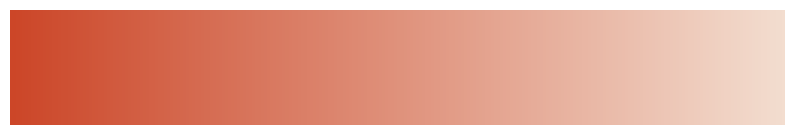

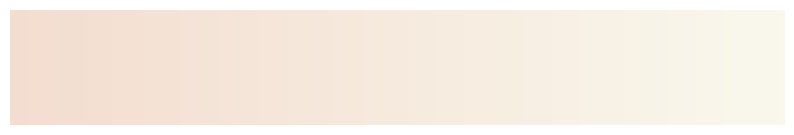

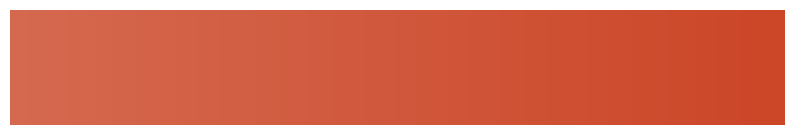

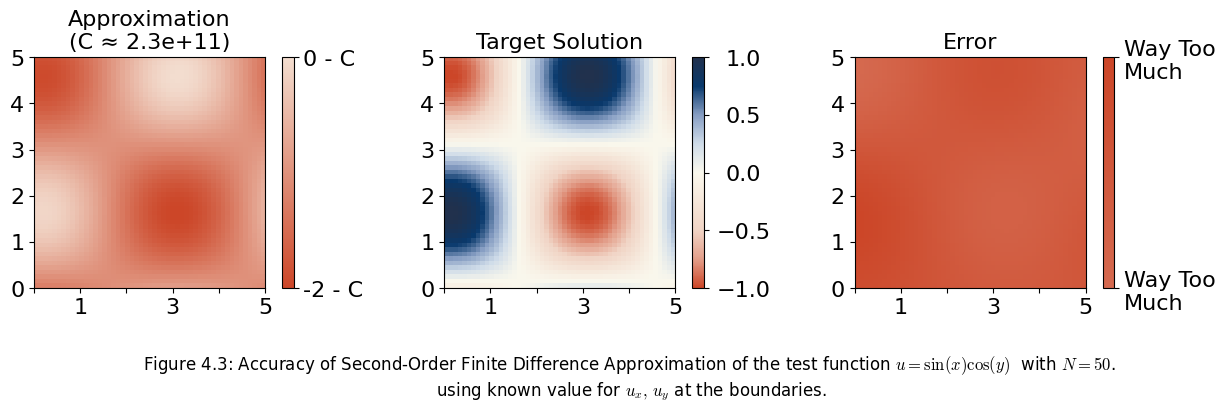

In [43]:
from matplotlib.colors import TwoSlopeNorm

zero_val = 0
max_val = 0.15,
min_val = 1.0

data_max = np.max(u_approx)
data_min = np.min(u_approx)

side1 = LinearSegmentedColormap.from_list(
    "side1",
    [
        red_shades(min_val),
        red_shades(max_val)
    ]
)
show_gradient(side1)

side2 = LinearSegmentedColormap.from_list(
    "side2",
    [
        red_shades(max_val),
        red_shades(zero_val)
    ]
)
show_gradient(side2)

error_joke = LinearSegmentedColormap.from_list(
    "error_joke",
    [
        red_shades(0.8),
        red_shades(1.0)
    ]
)
show_gradient(error_joke)

x = np.linspace(0, 5, N+1)
y = np.linspace(0, 5, N+1)

fig, ax = plt.subplots(1, 3, figsize=(15, 3))

norm = TwoSlopeNorm(vmin=data_min, vcenter=(data_min+data_max)/2, vmax=data_max)

im0 = ax[0].imshow(
    u_approx.reshape((N+1, N+1)),
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap=side1,
    # norm=norm
    )
value = f"{np.abs(data_min):.1e}"

sign = "-" if data_min < 0 else "+"

ax[0].set_title(f"Approximation\n(C \u2248 {value})")
ax[0].title.set_fontsize(16)
ax[0].set_xticks([0, 1, 2, 3, 4, 5])

im1 = ax[1].imshow(
    u_soln,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap=mines_cmap_div)
ax[1].set_title("Target Solution")
ax[1].title.set_fontsize(16)
ax[1].set_xticks([0, 1, 2, 3, 4, 5])

err = np.abs(u_approx.reshape((N+1, N+1)) - u_soln)

im2 = ax[2].imshow(
    err,
    cmap=error_joke,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()])
ax[2].set_title("Error")
ax[2].title.set_fontsize(16)
ax[2].set_xticks([0, 1, 2, 3, 4, 5])

for a in ax:
    a.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"{x:g}"
            if np.any(np.isclose(x, [1,3, 5]))
            else ""
        )
    )

for a in ax:
    a.tick_params(axis="both", which="major", labelsize=16)

cb = [fig.colorbar(im0, ax=ax[0]), fig.colorbar(im1, ax=ax[1]), fig.colorbar(im2, ax=ax[2])]
for i, c in enumerate(cb):
    c.ax.tick_params(labelsize=16)
    if i == 1:
        c.set_ticks([-1, -0.5, 0, 0.5, 1])
        for label in c.ax.get_yticklabels():
            label.set_horizontalalignment('center')
        c.ax.yaxis.set_tick_params(pad=25)

    elif i == 0:
        c.set_ticks([data_min, data_max])
        c.set_ticklabels([f"-2 {sign} C", f"0 {sign} C"])

    elif i == 2:
        c.set_ticks([np.min(err), np.max(err)])
        c.set_ticklabels(["Way Too \nMuch", "Way Too \nMuch"])

fig.text(
    0.55, -0.25,
    "Figure 4.3: Accuracy of Second-Order Finite Difference "+ r"Approximation of the test function $u=\sin(x)\cos(y)$  with $N=50$." \
        + "\n using known value for " + r"$u_x,\,u_y$" + " at the boundaries.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

plt.show()


In [44]:
fig.savefig(
    "figure_4_3.pdf",
    bbox_inches="tight"
)

Explanation of why Neumann fails:

The governing equations are only concerned with the first and second derivatives of u. 

The fundamental theorem of calculus reminds us that integrating an undefined function gets us an arbitrary constant:

$$
    \int g(x)\,dx = \int g(x)\,dx\,+C
$$

That tells us:

$$
    u \text{ solves some property based on } u_x,\,u_y \implies u+C \text{ solves the same property.}
$$

Therefore, the linear equation for $u_{i,j}$ is *underdetermined* and will be correct, +/- a constant, $C$. Which, based on the solver used, can be close to the maximum magnitude the machine can compute. Like 2.3e11, for instance:

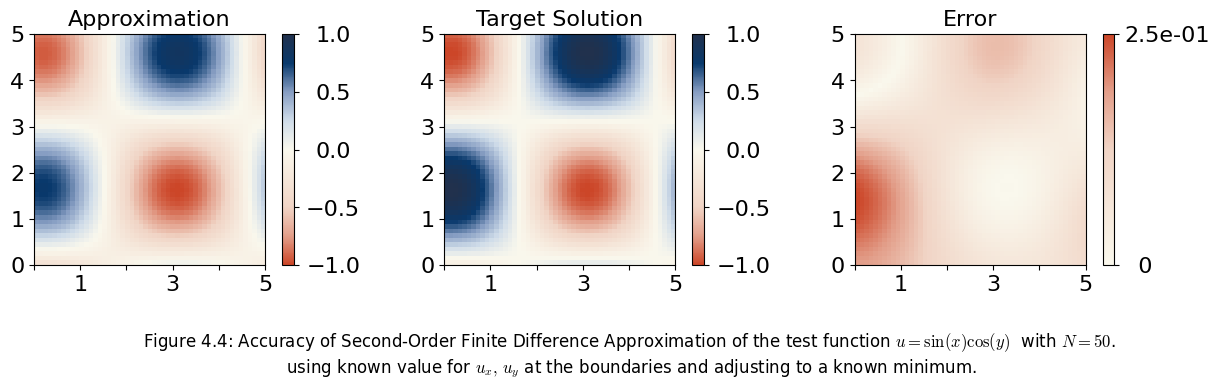

In [45]:
#If we want to map u_approx's min to -1...

u_min = np.min(u_approx)

u_approx_adjust = u_approx - u_min - 1

fig, ax = plt.subplots(1, 3, figsize=(15, 3))

im0 = ax[0].imshow(u_approx_adjust.reshape((N+1, N+1)), 
    cmap=mines_cmap_div,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
)
ax[0].set_title("Approximation")
ax[0].title.set_fontsize(16)
# cb0 = fig.colorbar(im0, ax=ax[0])
# cb0.ax.tick_params(labelsize=16)
ax[0].set_xticks([0, 1, 2, 3, 4, 5])

im1 = ax[1].imshow(u_soln, 
    cmap=mines_cmap_div,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()])
ax[1].set_title("Target Solution")
ax[1].title.set_fontsize(16)
# cb1 = fig.colorbar(im1, ax=ax[1])
# cb1.ax.tick_params(labelsize=16)
ax[1].set_xticks([0, 1, 2, 3, 4, 5])

err = np.abs(u_approx_adjust.reshape((N+1, N+1)) - u_soln)

im2 = ax[2].imshow(err, 
    cmap=mines_cmap_err,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()])
ax[2].set_title("Error")
ax[2].title.set_fontsize(16)
# cb2 = fig.colorbar(im2, ax=ax[2])
# cb2.ax.tick_params(labelsize=16)
ax[2].set_xticks([0, 1, 2, 3, 4, 5])

for a in ax:
    a.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"{x:g}"
            if np.any(np.isclose(x, [1,3, 5]))
            else ""
        )
    )

for a in ax:
    a.tick_params(axis="both", which="major", labelsize=16)

cb = [fig.colorbar(im0, ax=ax[0]), fig.colorbar(im1, ax=ax[1]), fig.colorbar(im2, ax=ax[2])]
for i, c in enumerate(cb):
    c.ax.tick_params(labelsize=16)
    if i < 2:
        c.set_ticks([-1, -0.5, 0, 0.5, 1])
        for label in c.ax.get_yticklabels():
            label.set_horizontalalignment("center")
        c.ax.yaxis.set_tick_params(pad=25)

    else:
        c.set_ticks([0, np.max(err)])
        c.set_ticklabels(["  0", f"{np.max(err):.1e}"])

fig.text(
    0.55, -0.25,
    "Figure 4.4: Accuracy of Second-Order Finite Difference "+ r"Approximation of the test function $u=\sin(x)\cos(y)$  with $N=50$." \
        + "\n using known value for " + r"$u_x,\,u_y$" + " at the boundaries and adjusting to a known minimum.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

plt.show()

In [46]:
fig.savefig(
    "figure_4_4.pdf",
    bbox_inches="tight"
)

In [47]:
#Let's just add a single line to the Neumann code to try and resolve the underdetermined system.

A = sp.sparse.vstack([A, np.ones((1, (N+1)**2))])
b = np.concatenate([b, [0]])

In [48]:
[A.shape, b.shape]

[(2602, 2601), (2602,)]

In [49]:
#Instead of dirichlet we're doing neumann boundary conditions

N = 50
a = 0
b = 5
h = (b - a) / N

# Create the grid including ghost points
x_vals = np.row_stack([np.linspace(a-h, b+h, N+1), np.linspace(a-h, b+h, N+1)])

#Row for every interior (real) grid point, column for every grid point including ghost points
#Then, also a row for every boundary point
A_int = sp.sparse.lil_matrix(((N-1)**2, (N+1)**2))

def get_row_index(i, j, N):
    return i * (N + 1) + j

for i in range(1, N):
    for j in range(1, N):
        A_int[get_interior_index(i,j,N), get_row_index(i, j, N)] = -4
        A_int[get_interior_index(i, j, N), get_row_index(i-1, j, N)] = 1
        A_int[get_interior_index(i, j, N), get_row_index(i+1, j, N)] = 1
        A_int[get_interior_index(i, j, N), get_row_index(i, j-1, N)] = 1
        A_int[get_interior_index(i, j, N), get_row_index(i, j+1, N)] = 1
A_int=A_int.tocsr()  * (1 / h**2)

f_vec = np.zeros((N-1)**2)

for i in range(1, N):
    for j in range(1, N):
        f_vec[get_interior_index(i, j, N)] = f([x_vals[0][i], x_vals[1][j]])

def u_x(x):
    return np.cos(x[0])*np.cos(x[1])

def u_y(x):
    return -np.sin(x[0])*np.sin(x[1])

def u_xx(x):
    return -np.sin(x[0])*np.cos(x[1])

def u_yy(x):
    return -np.cos(x[0])*np.sin(x[1])

#Rows of a new matrix A_bd for the boundary conditions
A_bd = sp.sparse.lil_matrix((4*N, (N+1)**2))
v_bd = np.zeros(4*N)

#Determine the row index for the conditions on the boundary matrix

i = 0
for j in range(0, N+1):
    v_bd[j] = u_xx([x_vals[0][i], x_vals[1][j]]) + (2/h) * u_x([x_vals[0][i], x_vals[1][j]])
    A_bd[j, get_row_index(i+1, j, N)] = 2/(h**2)
    A_bd[j, get_row_index(i, j, N)] = -2/(h**2)

#Bottom boundary i=N
i = N
for j in range(0, N+1):
    v_bd[N+1+j] = u_xx([x_vals[0][i], x_vals[1][j]]) - (2/h) * u_x([x_vals[0][i], x_vals[1][j]])
    A_bd[N+1+j, get_row_index(i-1, j, N)] = 2/(h**2)
    A_bd[N+1+j, get_row_index(i, j, N)] = -2/(h**2)

#Left boundary j=0
j = 0
for i in range(1, N):
    v_bd[2*N+i+1] = u_yy([x_vals[0][i], x_vals[1][j]]) + (2/h) * u_y([x_vals[0][i], x_vals[1][j]])
    A_bd[2*N+i+1, get_row_index(i, j+1, N)] = 2/(h**2)
    A_bd[2*N+i+1, get_row_index(i, j, N)] = -2/(h**2)

#Right boundary j=N
j = N
for i in range(1, N):
    v_bd[3*N+i] = u_yy([x_vals[0][i], x_vals[1][j]]) - (2/h) * u_y([x_vals[0][i], x_vals[1][j]])
    A_bd[3*N+i, get_row_index(i, j-1, N)] = 2/(h**2)
    A_bd[3*N+i, get_row_index(i, j, N)] = -2/(h**2)


A = sp.sparse.vstack([A_int, A_bd]).tocsr()
b = np.concatenate([f_vec, v_bd])

A[-1,:] = 0

for i in range(N+1):
    for j in range(N+1):
        if i == 0 or i == N or j == 0 or j == N:
            A[-1, get_row_index(i, j, N)] = 1

b[-1] = 0

u_approx = sp.sparse.linalg.spsolve(A, b)

u_soln = np.zeros((N+1, N+1))
for i in range(N+1):
    for j in range(N+1):
        u_soln[i, j] = u([x_vals[0][i], x_vals[1][j]])

C:\Users\cjgir\AppData\Local\Temp\ipykernel_34404\3662747541.py:9: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  x_vals = np.row_stack([np.linspace(a-h, b+h, N+1), np.linspace(a-h, b+h, N+1)])
C:\Users\cjgir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\sparse\_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


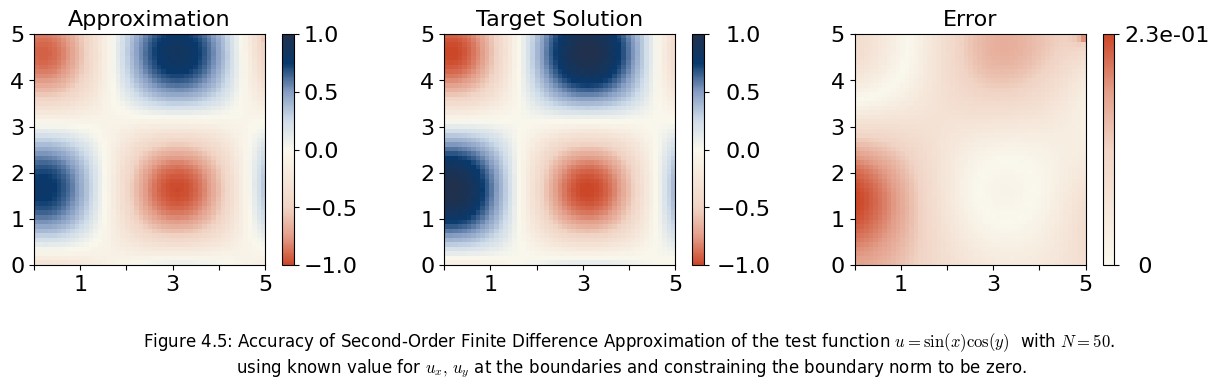

In [52]:

fig, ax = plt.subplots(1, 3, figsize=(15, 3))

im0 = ax[0].imshow(
    u_approx.reshape((N+1, N+1)),
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap=mines_cmap_div,
    norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    )
value = f"{np.abs(data_min):.1e}"

sign = "-" if data_min < 0 else "+"

ax[0].set_title("Approximation")
ax[0].title.set_fontsize(16)
ax[0].set_xticks([0, 1, 2, 3, 4, 5])

im1 = ax[1].imshow(
    u_soln,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap=mines_cmap_div)
ax[1].set_title("Target Solution")
ax[1].title.set_fontsize(16)
ax[1].set_xticks([0, 1, 2, 3, 4, 5])

err = np.abs(u_approx.reshape((N+1, N+1)) - u_soln)

im2 = ax[2].imshow(
    err,
    cmap=mines_cmap_err,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()])
ax[2].set_title("Error")
ax[2].title.set_fontsize(16)
ax[2].set_xticks([0, 1, 2, 3, 4, 5])

for a in ax:
    a.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"{x:g}"
            if np.any(np.isclose(x, [1,3, 5]))
            else ""
        )
    )

for a in ax:
    a.tick_params(axis="both", which="major", labelsize=16)

cb = [fig.colorbar(im0, ax=ax[0]), fig.colorbar(im1, ax=ax[1]), fig.colorbar(im2, ax=ax[2])]
for i, c in enumerate(cb):
    c.ax.tick_params(labelsize=16)
    if i == 1:
        c.set_ticks([-1, -0.5, 0, 0.5, 1])
        for label in c.ax.get_yticklabels():
            label.set_horizontalalignment('center')
        c.ax.yaxis.set_tick_params(pad=25)

fig.text(
    0.55, -0.25,
    "Figure 4.5: Accuracy of Second-Order Finite Difference "+ r"Approximation of the test function $u=\sin(x)\cos(y)$  with $N=50$." \
        + "\n using known value for " + r"$u_x,\,u_y$" + " at the boundaries and constraining the boundary norm to be zero.",
    ha="center",
    fontsize=12,
    fontfamily="DejaVu Sans"
)

cb[2].set_ticks([0, np.max(err)])
cb[2].set_ticklabels(["  0", f"{np.max(err):.1e}"])

plt.show()

In [53]:
fig.savefig(
    "figure_4_5.pdf",
    bbox_inches="tight"
)